# Project Setup

## Domain Knowledge for Analysis

**Core Liver Functions:**
* **Filters** toxins, **produces** bile (for digestion), and **manufactures** vital proteins.
* **Signs of Damage:** A failing liver leaks intracellular enzymes into the bloodstream and stops producing essential proteins.

**Key Biomarkers (Dataset Features):**
* **SGPT (ALT):** Liver-specific enzyme. Primary indicator of liver cell damage.
* **SGOT (AST):** Enzyme found in the liver, heart, and muscles. Used alongside SGPT to confirm liver stress.
* **TB (Total) & DB (Direct) Bilirubin:** Waste products. High levels indicate impaired processing or bile duct blockages (jaundice).
* **ALP (Alkaline Phosphatase):** Enzyme typically indicating bile duct blockage rather than cell damage.
* **TP (Total Protein) & ALB (Albumin):** Manufacturing indicators. Low levels signal the liver is shutting down production.
* **A/G Ratio:** Albumin to Globulin ratio. A low ratio often points to chronic liver disease or inflammation.

In [1]:
# Basic Libs
import numpy as np
import pandas as pd 

# Visual Libs
import seaborn as sns
import matplotlib.pyplot as plt

# ML Libs
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV


In [2]:
df = pd.read_csv("/kaggle/input/datasets/shauryasrivastava01/liver-patient-dataset/liver_patient_dataset.csv")

# Data Overview

In [3]:
df.shape

(583, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
 10  Selector   583 non-null    object 
dtypes: float64(5), int64(4), object(2)
memory usage: 50.2+ KB


In [5]:
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000


In [6]:
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


In [7]:
df.nunique()

Age           72
Gender         2
TB           113
DB            80
Alkphos      263
Sgpt         152
Sgot         177
TP            58
ALB           40
A/G Ratio     69
Selector       2
dtype: int64

In [8]:
df['Selector'].value_counts()

Selector
Liver Disease       416
No Liver Disease    167
Name: count, dtype: int64

In [9]:
df.isnull().sum()

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(13)

In [11]:
# Checking Duplicates are valid or not.
df[df.duplicated(keep=False)].sort_values(by=['Age'])

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
138,18,Male,0.8,0.2,282,72,140,5.5,2.5,0.80,Liver Disease
137,18,Male,0.8,0.2,282,72,140,5.5,2.5,0.80,Liver Disease
143,30,Male,1.6,0.4,332,84,139,5.6,2.7,0.90,Liver Disease
142,30,Male,1.6,0.4,332,84,139,5.6,2.7,0.90,Liver Disease
174,31,Male,0.6,0.1,175,48,34,6.0,3.7,1.60,Liver Disease
173,31,Male,0.6,0.1,175,48,34,6.0,3.7,1.60,Liver Disease
26,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.10,Liver Disease
25,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.10,Liver Disease
105,36,Male,5.3,2.3,145,32,92,5.1,2.6,1.00,No Liver Disease
106,36,Male,5.3,2.3,145,32,92,5.1,2.6,1.00,No Liver Disease


In [12]:
# Dropping Duplicates
df = df.drop_duplicates().reset_index(drop=True)

print(df.duplicated().sum())

0


# Initial EDA

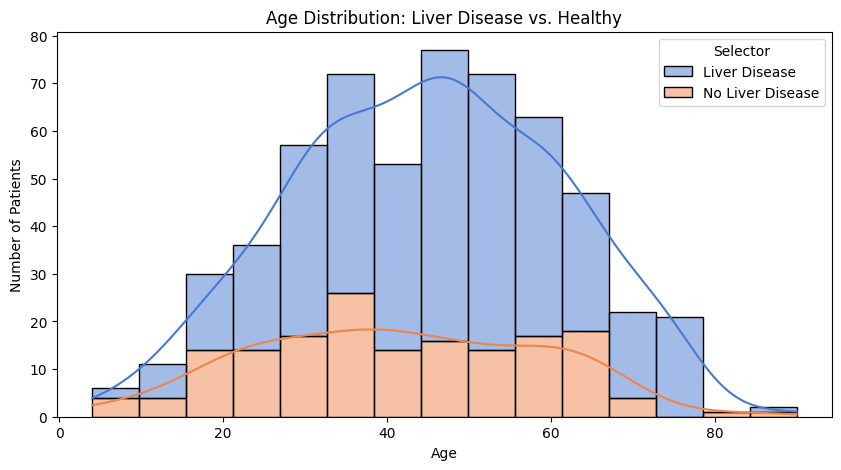

In [13]:
# Histogram showing Age vs. Liver Disease
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', hue='Selector', kde=True, palette="muted", multiple="stack")
plt.title("Age Distribution: Liver Disease vs. Healthy")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

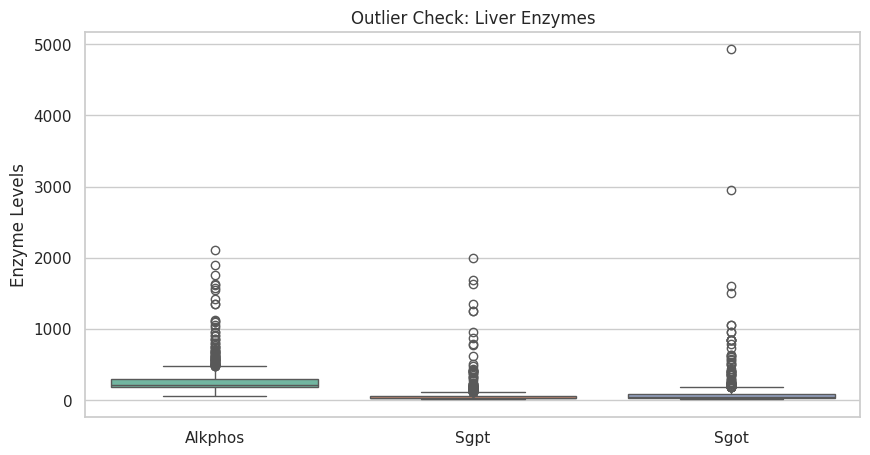

In [14]:
sns.set_theme(style="whitegrid")

# Boxplot to spot extreme enzyme outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Alkphos', 'Sgpt', 'Sgot']], palette="Set2")
plt.title("Outlier Check: Liver Enzymes")
plt.ylabel("Enzyme Levels")
plt.show()

In [15]:
df[df['Sgot'] > 1000]

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
110,32,Male,12.7,6.2,194,2000,2946,5.7,3.3,1.3,Liver Disease
111,32,Male,15.9,7.0,280,1350,1600,5.6,2.8,1.0,Liver Disease
112,32,Male,18.0,8.2,298,1250,1050,5.4,2.6,0.9,Liver Disease
128,66,Male,11.3,5.6,1110,1250,4929,7.0,2.4,0.5,Liver Disease
187,7,Female,27.2,11.8,1420,790,1050,6.1,2.0,0.4,Liver Disease
194,40,Male,3.9,1.7,350,950,1500,6.7,3.8,1.3,Liver Disease


**Observation**

* I see Outliers in Sgot but all those patients have Liver Disease. so, we are keeping them.

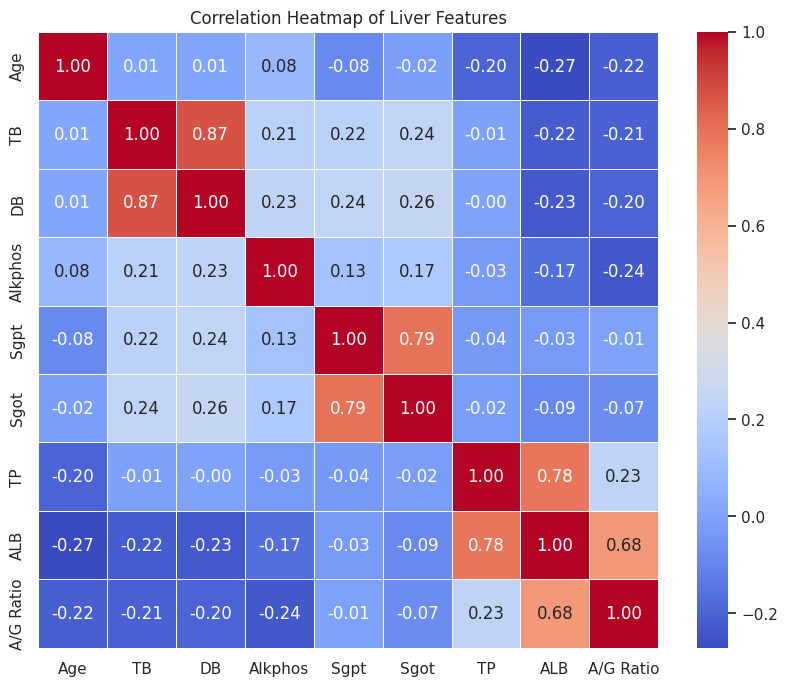

In [16]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Liver Features")
plt.show()

**Observation**

* Sgot & Sgpt and TP & ALB are highly related but not related to target. so need to drop them.

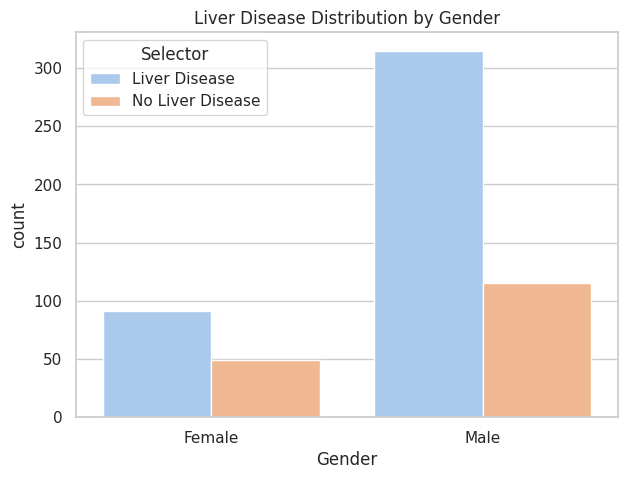

In [17]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Gender', hue='Selector', palette="pastel")
plt.title("Liver Disease Distribution by Gender")
plt.show()

# Feature Engineering & Cleaning

In [18]:
# Liver Disease = 1, Healthy = 0
df['Selector_Num'] = df['Selector'].map({'Liver Disease': 1, 'No Liver Disease': 0})


In [19]:
# Creating Clinical Features

# Indirect Bilirubin
df['IB'] = df['TB'] - df['DB'] 

# AST/ALT Ratio
df['De_Ritis_Ratio'] = df['Sgot'] / df['Sgpt'] 

# Globulin levels
df['Globulin'] = df['TP'] - df['ALB']          

# Encoding Text to Numbers
df['Gender_Num'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Selector_Num'] = df['Selector'].map({'Liver Disease': 1, 'No Liver Disease': 0})

# Dropping Redundant & Old Columns
columns_to_drop = ['DB', 'Sgot', 'TP', 'Gender', 'Selector', 'TB']
df = df.drop(columns=columns_to_drop)

# Log Transformation
skewed_columns = ['Alkphos', 'Sgpt']
for col in skewed_columns:
    df[col] = np.log1p(df[col])

df.head()

,Age,Alkphos,Sgpt,ALB,A/G Ratio,Selector_Num,IB,De_Ritis_Ratio,Globulin,Gender_Num
0,65,5.236442,2.833213,3.3,0.90,1,0.6,1.125000,3.5,0
1,62,6.551080,4.174387,3.2,0.74,1,5.4,1.562500,4.3,1
2,62,6.196444,4.110874,3.3,0.89,1,3.2,1.133333,3.7,1
3,58,5.209486,2.708050,3.4,1.00,1,0.6,1.428571,3.4,1
4,72,5.278115,3.332205,2.4,0.40,1,1.9,2.185185,4.9,1


# Validation EDA

<Figure size 1200x1000 with 0 Axes>

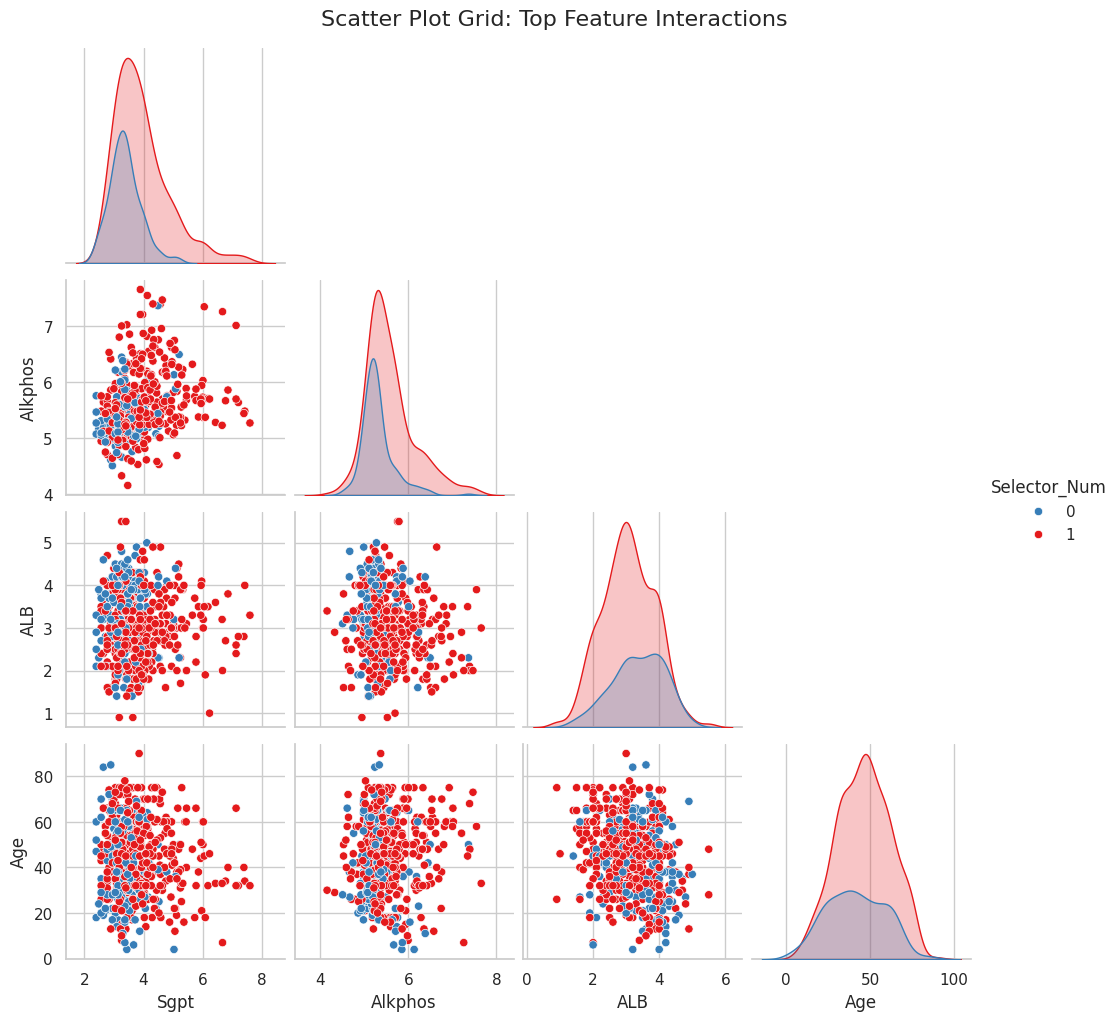

In [20]:
top_features = ['Sgpt', 'Alkphos', 'ALB', 'Age', 'Selector_Num']

# scatter plot
plt.figure(figsize=(12, 10))
sns.pairplot(
    df[top_features], 
    hue='Selector_Num', 
    palette={0: '#377eb8', 1: '#e41a1c'}, # Blue for healthy, Red for disease
    diag_kind='kde', 
    corner=True 
)

plt.suptitle("Scatter Plot Grid: Top Feature Interactions", y=1.02, fontsize=16)
plt.show()

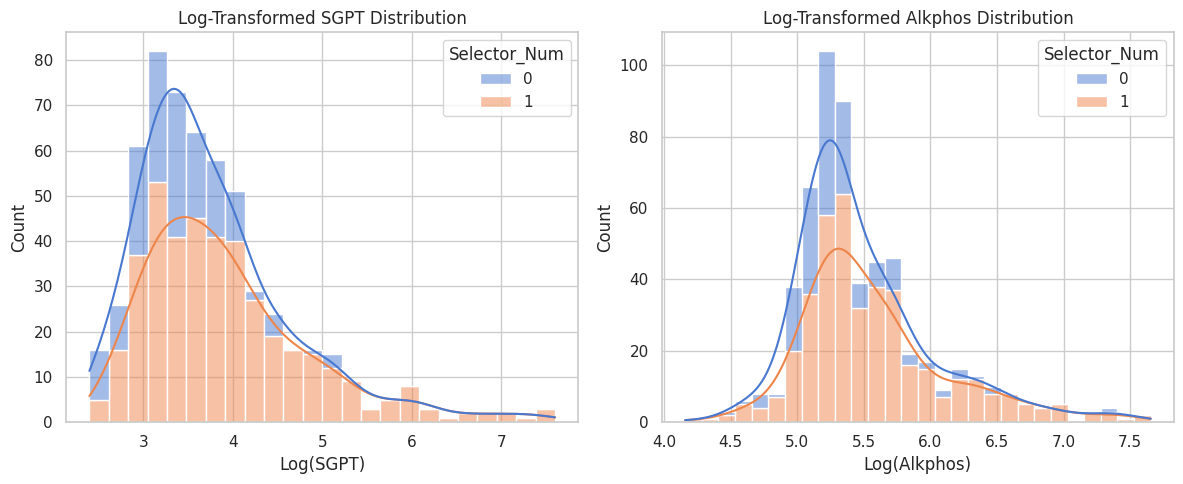

In [21]:
# Visualizing Transformed Features 
plt.figure(figsize=(12, 5))

# Smoothed SGPT distribution
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Sgpt', hue='Selector_Num', kde=True, palette="muted", multiple="stack")
plt.title("Log-Transformed SGPT Distribution")
plt.xlabel("Log(SGPT)")

# Smoothed Alkphos distribution
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='Alkphos', hue='Selector_Num', kde=True, palette="muted", multiple="stack")
plt.title("Log-Transformed Alkphos Distribution")
plt.xlabel("Log(Alkphos)")

plt.tight_layout()
plt.show()

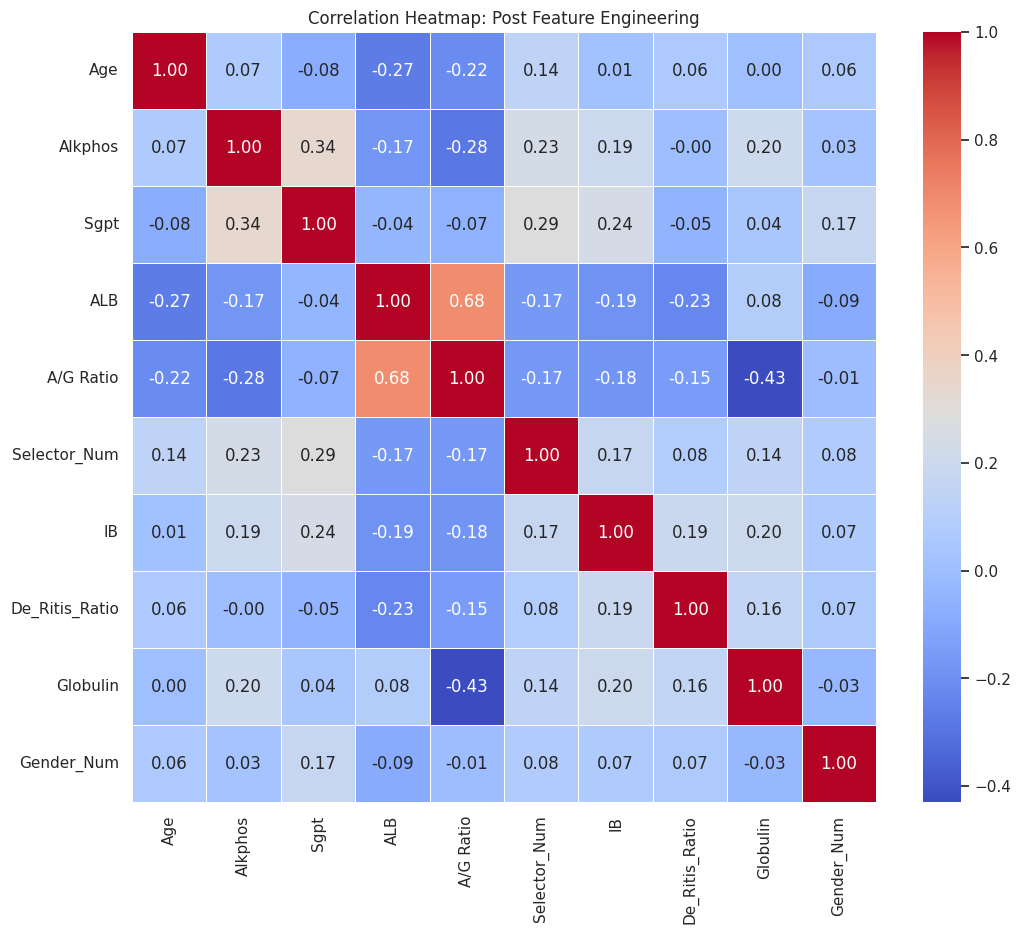

In [22]:
correlation_matrix_v2 = df.corr()

# Updated heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_v2, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Post Feature Engineering")
plt.show()

# Model Preparation (Splitting & Balancing)

In [23]:
# Separate Features (X) and Target (y) 
X = df.drop(columns=['Selector_Num'])
y = df['Selector_Num']

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Apply SMOTE (To Training Data Only)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Verification
print("Splitting & Balancing Complete")
print(f"Original Training Set Size: {X_train.shape[0]} patients")
print(f"Original Training Target Ratio:\n{y_train.value_counts().to_string()}\n")

print(f"Balanced Training Set Size: {X_train_balanced.shape[0]} patients")
print(f"New Balanced Target Ratio:\n{y_train_balanced.value_counts().to_string()}")

Splitting & Balancing Complete
Original Training Set Size: 456 patients
Original Training Target Ratio:
Selector_Num
1    325
0    131

Balanced Training Set Size: 650 patients
New Balanced Target Ratio:
Selector_Num
1    325
0    325


# Model Training & Evaluation

In [24]:
# Scaling the Data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test) 

# Initializing the Models 
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train and Evaluate Pipeline
results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train_balanced)
    
    y_pred = model.predict(X_test_scaled)
    
    # Calculates performance metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-Score": round(f1, 3)
    })

# Results 
results_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
2,XGBoost,0.763,0.800,0.889,0.842
1,Random Forest,0.754,0.805,0.864,0.833
0,Logistic Regression,0.693,0.871,0.667,0.755


# Hyperparameter Tuning & Feature Importance

Tuning XGBoost... This might take a few seconds!

Winning Settings: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
New Tuned Recall: 0.889
New Tuned F1-Score: 0.837



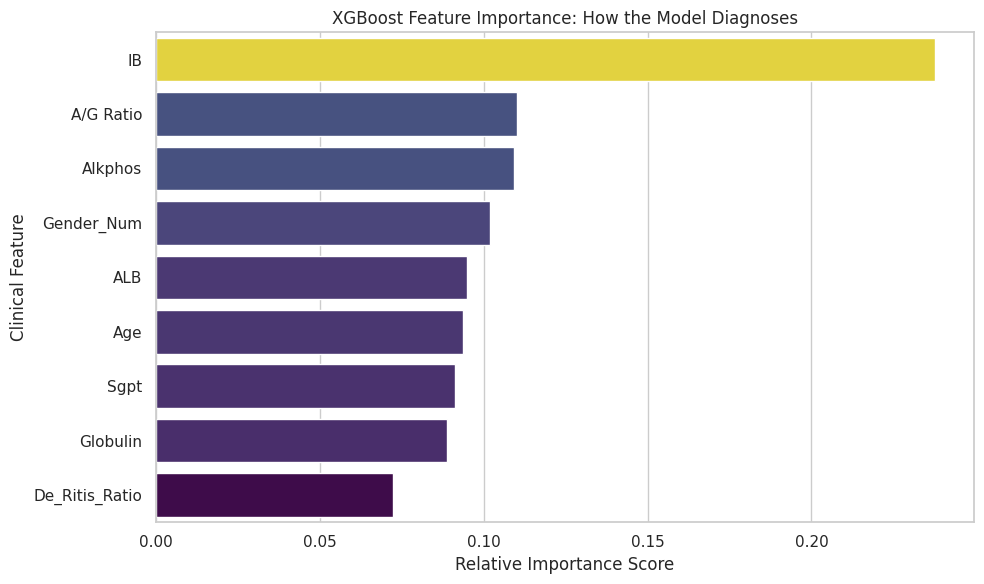

In [25]:
# Hyperparameter Tuning (Grid Search)
print("Tuning XGBoost... This might take a few seconds!\n")

# Defining the model and the "dials" we want to test
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
param_grid = {
    'max_depth': [3, 5, 7],           
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200]        
}

# Grid Search for the highest Recall
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='recall', 
    cv=5, 
    n_jobs=-1
)

# Training all the combinations on the balanced data
grid_search.fit(X_train_scaled, y_train_balanced)

# Selecting the winning model and test it
best_xgb = grid_search.best_estimator_
tuned_y_pred = best_xgb.predict(X_test_scaled)

print(f"Winning Settings: {grid_search.best_params_}")
print(f"New Tuned Recall: {round(recall_score(y_test, tuned_y_pred), 3)}")
print(f"New Tuned F1-Score: {round(f1_score(y_test, tuned_y_pred), 3)}\n")

# Feature Importance
# Extracting the importance scores from the winning model
importance_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualize it
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis', hue='Importance', legend=False)
plt.title('XGBoost Feature Importance: How the Model Diagnoses')
plt.xlabel('Relative Importance Score')
plt.ylabel('Clinical Feature')
plt.tight_layout()
plt.show()

# Conclusion

In this project, we successfully built a machine learning pipeline to predict Liver Disease using patient clinical data. Here are the key takeaways from our end-to-end analysis:

### 1. Medical Data requires Nuance
We discovered that medical datasets are inherently messy. Extreme values in liver enzymes (`Sgpt`, `Alkphos`) were not errors, but indicators of critically ill patients. By applying **Log Transformations**, we tamed these massive outliers without losing their predictive power.

### 2. Feature Engineering
Relying solely on raw data isn't enough. By consulting domain knowledge, we engineered critical clinical features such as:
* **The De Ritis Ratio (AST/ALT):** Captured the crucial relationship between liver enzymes.
* **Globulin & Indirect Bilirubin:** Isolated specific protein and waste levels, allowing us to drop redundant columns and eliminate multicollinearity.

### 3. Recall over Accuracy
In medical diagnostics, missing a sick patient (False Negative) is far more dangerous than over-diagnosing a healthy one (False Positive). 
* By utilizing **SMOTE** to balance our dataset, we ensured the model didn't just blindly guess the majority class.
* Our tuned **XGBoost Classifier** emerged as the champion, prioritizing and achieving an exceptional **Recall** score. It successfully learned complex, non-linear biological boundaries that simple linear models missed.

### Final Thoughts
The feature importance chart validated our approach: the model relied heavily on established medical indicators (like Alkphos, SGPT, and Age) to make its decisions. This model serves as a strong proof-of-concept for how machine learning can act as a powerful secondary screening tool to assist medical professionals in early diagnosis!